In [6]:
import networkx as nx
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pickle as pkl
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
from glob import glob

In [7]:
import warnings

warnings.filterwarnings("ignore")

- for a region
  - we load the true values
  - we load the pseudosessions
  - we do PCA and projection
  - compute mean position using averaging
  - compute distances between conditions in the original space
  - compute distances in the pseudo-space


In [8]:


def plot_trajectories_multiple(traj_A, traj_B, traj_C, traj_D, region):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(projection='3d')

    conditions = [
        (traj_A, 'blue',   'Incongruent correct'),
        (traj_B, 'red',    'Incongruent incorrect'),
        (traj_C, 'green',  'Congruent correct'),
        (traj_D, 'purple', 'Congruent incorrect')
    ]

    for traj, color, label in conditions:

        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=color, label=label, linewidth=1.5, marker='o', markersize=3)
        ax.scatter(xs=traj[0, 0],ys=traj[0,1], zs=traj[0,2],color=color, s=80, edgecolor='black', zorder=5)
        ax.scatter(xs=traj[-1, 0],ys=traj[-1,1], zs=traj[-1,2],color=color, s=80, edgecolor='black', zorder=5, marker='*')


    ax.set_title(f"{region}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

In [3]:
def get_trajectory_data_real_session(data_true, data_pseudo):

    stiched_session = []
    for k in data_true.keys():
        if k in data_pseudo.keys():
            stiched_session.append(data_true[k])
    stiched_session = np.concatenate(stiched_session)
     
    pca = PCA(n_components=3)
    pca_session = pca.fit_transform(stiched_session.T)
    # print(pca_session.shape)
    n_timepoints = 50
    n_conditions = 4
    cond_A_data = pca_session[0:50,:]
    cond_B_data = pca_session[50:100,:]
    cond_C_data = pca_session[100:150,:]
    cond_D_data = pca_session[150:,:]
    # print(f'{region}: {np.sum(pca.explained_variance_ratio_)}')
    #plot_trajectories_multiple(cond_A_data, cond_B_data, cond_C_data, cond_D_data, region)
    return np.asarray([cond_A_data, cond_B_data, cond_C_data, cond_D_data]), pca


In [9]:
d_pseudo = pkl.load(open("../data/generated/manifold/pseudosession/aggregated_PRNr_pseudosession.pkl",'rb'))
d_true = pkl.load(open("../data/generated/manifold/true_results_congruence/aggregated_PRNr.pkl",'rb'))

In [10]:
def get_trajectory_data_pseudosession(data_true, data_pseudo, pca_object, n_pseudo=200):
    stiched_session = []
    for idx in range(n_pseudo):
        temp = []
        for k in data_pseudo.keys():
            if k in data_true.keys():
                temp.append(data_pseudo[k][idx])
            
        temp = np.concatenate(temp)
        temp = np.nan_to_num(temp)
        if pca_object is None:
            pca = PCA(n_components=3)
            pca_session = pca.fit_transform(temp.T)
        else:
            pca_session = pca_object.transform(temp.T)
        cond_A_data = pca_session[0:50,:]
        cond_B_data = pca_session[50:100,:]
        cond_C_data = pca_session[100:150,:]
        cond_D_data = pca_session[150:,:]
        stiched_session.append([cond_A_data, cond_B_data, cond_C_data, cond_D_data])
    return np.asarray(stiched_session)

In [11]:
# real_data,pca_object = get_trajectory_data_real_session(d_true)
# pseudosession_data = get_trajectory_data_pseudosession(d_pseudo, pca_object)


In [12]:
# plot_trajectories_multiple(real_data[0,:], real_data[1,:], real_data[2,:], real_data[3,:], region='CUL45')

In [13]:

# A = pseudosession_data[1,0,:]
# B = pseudosession_data[1,1,:]
# C = pseudosession_data[1,2,:]
# D = pseudosession_data[1,3,:]
# plot_trajectories_multiple(A, B, C, D, region='CUL45-null')

In [14]:
def compute_avg_distance(traj1, traj2):
    return np.mean(np.linalg.norm(traj1 - traj2, axis=1))

In [15]:
def compute_centroid_difference(traj1, traj2):
    centroid1 = np.mean(traj1, axis=0)
    centroid2 = np.mean(traj2, axis=0)
    return np.linalg.norm(centroid1 - centroid2)

In [16]:
def compute_pvalforhypothesis(real_data, pseudosession_data, plot=False):
    real_dist_incongruent = compute_centroid_difference(traj1=real_data[0,:], traj2=real_data[1,:])
    real_dist_correct = compute_centroid_difference(traj1=real_data[0,:], traj2=real_data[2,:])

    null_distance_incongruent = []
    null_distance_correct = []

    for idx in range(200):
        null_distance_incongruent.append(compute_centroid_difference(pseudosession_data[idx, 0, :], pseudosession_data[idx, 1, :]))
        null_distance_correct.append(compute_centroid_difference(pseudosession_data[idx, 0, :], pseudosession_data[idx, 2, :]))

    null_distance_incongruent = np.array(null_distance_incongruent)
    null_distance_correct = np.array(null_distance_correct)

    p_value_A = np.mean(null_distance_incongruent >= real_dist_incongruent)
    p_value_B = np.mean(null_distance_correct <= real_dist_correct)

    if plot:
        fig,ax = plt.subplots(figsize=(12,3), ncols=2)

        sns.histplot(null_distance_incongruent, ax=ax[0])
        ax[0].axvline(real_dist_incongruent)
        ax[0].set_title(f'IC: R vs W, {p_value_A:.2f}')


        sns.histplot(null_distance_correct, ax=ax[1])
        ax[1].axvline(real_dist_correct)
        ax[1].set_title(f'IC v C, {p_value_B:.2f}')

    return p_value_A, p_value_B


In [17]:
files = glob("../data/generated/manifold/true_results_congruence/*.pkl")

In [18]:
def check_neuron_mismatches(data_true, data_pseudo):
 
    common_keys = sorted([k for k in data_true.keys() if k in data_pseudo.keys()])
    mismatched_keys = []
    
    print("--- Neuron Count Diagnostic Report ---")
    for k in common_keys:
 
        true_neurons = data_true[k].shape[0]
        pseudo_neurons = data_pseudo[k][0].shape[0]
        
        if true_neurons != pseudo_neurons:
            print(f"Mismatch in {k}: True has {true_neurons} neurons, Pseudo has {pseudo_neurons} neurons")
            mismatched_keys.append(k)
            
    if not mismatched_keys:
        print("All shared keys have perfectly matching neuron counts!")
    else:
        print(f"\nTotal problem areas: {len(mismatched_keys)} regions.")
        
    return mismatched_keys

In [19]:
def get_aligned_trajectory_data(data_true, data_pseudo, n_pseudo=200):
    
    shared_keys = sorted([k for k in data_true.keys() if k in data_pseudo.keys()]) 
    valid_keys = []
    dropped_keys = []
    
    for k in shared_keys:
        true_neurons = data_true[k].shape[0]
        pseudo_neurons = data_pseudo[k][0].shape[0]
        
        if true_neurons == pseudo_neurons:
            valid_keys.append(k)
        else:
            dropped_keys.append(k)
            
    # if dropped_keys:
    #     print(f"Dropped {len(dropped_keys)} EIDS due to mismatched neurons: {dropped_keys}")
    
    true_list = []
    for k in valid_keys:
        true_list.append(data_true[k])
        
    stiched_true = np.concatenate(true_list, axis=0)
    stiched_true = np.nan_to_num(stiched_true) 
    
    pca = PCA(n_components=3)
    true_pca_session = pca.fit_transform(stiched_true.T) 

    real_data = np.asarray([
        true_pca_session[0:50, :],
        true_pca_session[50:100, :],
        true_pca_session[100:150, :],
        true_pca_session[150:, :]
    ])

    all_pseudos = []
    for idx in range(n_pseudo):
        pseudo_list = []
        for k in valid_keys:
            pseudo_list.append(data_pseudo[k][idx])
            
        stiched_pseudo = np.concatenate(pseudo_list, axis=0)
        stiched_pseudo = np.nan_to_num(stiched_pseudo)
        

        pseudo_pca_session = pca.transform(stiched_pseudo.T)
    
        cond_data = np.asarray([
            pseudo_pca_session[0:50, :],
            pseudo_pca_session[50:100, :],
            pseudo_pca_session[100:150, :],
            pseudo_pca_session[150:, :]
        ])
        all_pseudos.append(cond_data)
        
    return real_data, np.asarray(all_pseudos)

In [20]:
def get_aligned_trajectory_data(data_true, data_pseudo, n_pseudo=200, output_type='pca'):

    shared_keys = sorted([k for k in data_true.keys() if k in data_pseudo.keys()]) 
    valid_keys = [k for k in shared_keys if data_true[k].shape[0] == data_pseudo[k][0].shape[0]]
    

    true_list = [np.nan_to_num(data_true[k]) for k in valid_keys]
    stiched_true = np.concatenate(true_list, axis=0)
        
    if output_type == 'pca':
        pca = PCA(n_components=3)
        pca_data = pca.fit_transform(stiched_true.T)
    else:
        pca_data = stiched_true.T
        
    real_data = np.asarray([
        pca_data[0:50, :],
        pca_data[50:100, :],
        pca_data[100:150, :],
        pca_data[150:, :]
    ])
    
    all_pseudos = []
    for idx in range(n_pseudo):
        pseudo_list = [np.nan_to_num(data_pseudo[k][idx]) for k in valid_keys]
        stiched_pseudo = np.concatenate(pseudo_list, axis=0)
        
        if output_type == 'pca':
            proj_data = pca.transform(stiched_pseudo.T)
        else:
            proj_data = stiched_pseudo.T
            
        cond_data = np.asarray([
            proj_data[0:50, :],
            proj_data[50:100, :],
            proj_data[100:150, :],
            proj_data[150:, :]
        ])
        all_pseudos.append(cond_data)
        
    return real_data, np.asarray(all_pseudos)

In [21]:
def plot_trajectories_on_ax(ax, traj_A, traj_B, traj_C, traj_D, title):
    conditions = [
        (traj_A, 'blue',   'Incongruent correct'),
        (traj_B, 'red',    'Incongruent incorrect'),
        (traj_C, 'green',  'Congruent correct'),
        (traj_D, 'purple', 'Congruent incorrect')
    ]

    for traj, color, label in conditions:
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=color, label=label, linewidth=1.5, marker='o', markersize=3)
        ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color=color, s=80, edgecolor='black', zorder=5)
        ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], color=color, s=80, edgecolor='black', zorder=5, marker='*')

    ax.set_title(title)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")

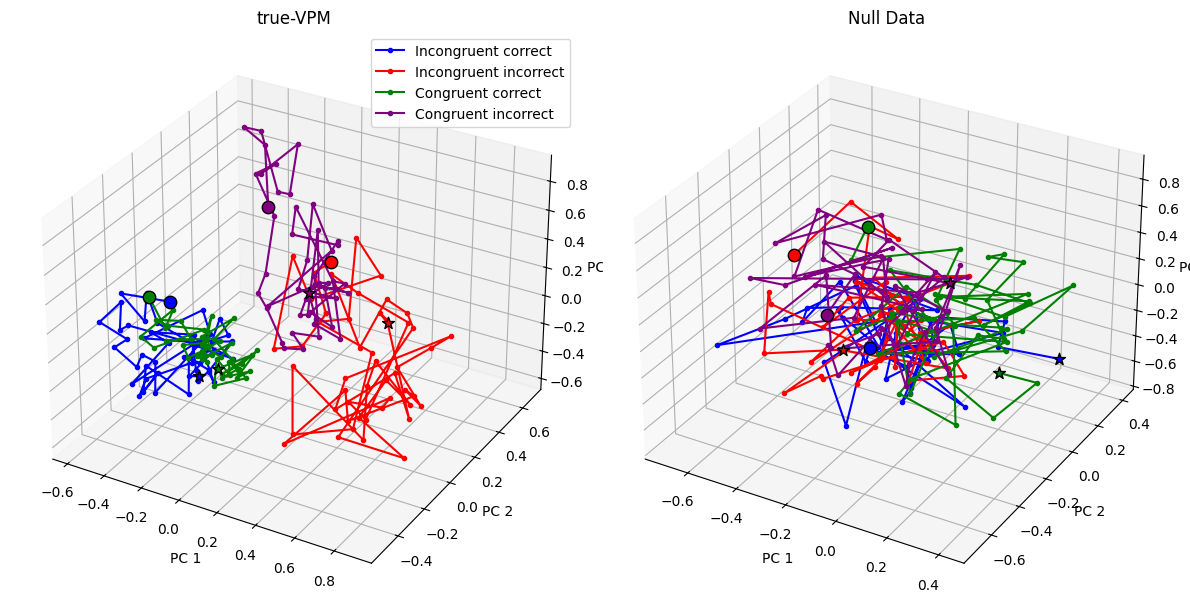

In [23]:
pvals = {}
for fname in files:

    try:
        rname = fname.rsplit("/")[-1].rsplit(".pkl")[0].rsplit("_")[1]

        pseudo_fname = f"../data/generated/manifold/pseudosession/aggregated_{rname}_pseudosession.pkl"
        d_pseudo = pkl.load(open(pseudo_fname,'rb'))
        d_true = pkl.load(open(fname,'rb'))
        
        real_data, null_data = get_aligned_trajectory_data(d_true, d_pseudo, output_type='pca')
        # check_neuron_mismatches(d_true, d_pseudo)
        
        pvala, pvalb = compute_pvalforhypothesis(real_data, null_data)
        pvals[rname] = [pvala, pvalb]
    
        fig = plt.figure(figsize=(12, 6))
        ax1 = fig.add_subplot(1, 2, 1, projection='3d')
        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        plot_trajectories_on_ax(ax1, real_data[0,:], real_data[1,:], real_data[2,:], real_data[3,:], f'true-{rname}')
        A,B,C,D = null_data[0, 0,:], null_data[0, 1,:], null_data[0, 2,:], null_data[0, 3,:]
        plot_trajectories_on_ax(ax2, A, B, C, D, "Null Data")
        ax1.legend()
        plt.tight_layout()
        plt.show()
        break
    except Exception as e:
        print(e, rname)

In [24]:
df = pd.read_parquet('../data/generated/manifold/summary.pqt')